In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ClassicalCode import ClassicalCode
from LogicalChannel import LogicalChannel, partial_trace_syndrome
from measures import trace_norm, blp_measure, logical_basis_state, max_blp_measure
from error_models import perfect_physical_error, perfect_syndrome, iid_bitflip_error, iid_syndrome

# Classical Code : Define, Distance, Distance Distribution

In [2]:
def _gf2_rank(M: np.ndarray) -> int:
    """Rank of a binary matrix over GF(2)."""
    A = (np.array(M, dtype=int) % 2).copy()
    rows, cols = A.shape
    rank = 0
    for c in range(cols):
        pivot = None
        for r in range(rank, rows):
            if A[r, c]:
                pivot = r
                break
        if pivot is None:
            continue
        A[[rank, pivot]] = A[[pivot, rank]]
        for r in range(rows):
            if r != rank and A[r, c]:
                A[r] = (A[r] + A[rank]) % 2
        rank += 1
    return rank


def sample_H_brute(n: int, k: int) -> np.ndarray:
    """Sample a full-rank binary parity-check matrix H of shape (n - k, n).

    Matches the ClassicalCode convention H.shape == (m, n) with m = n - k.
    Each entry is drawn uniformly from {0, 1}; matrices are re-sampled until
    the rows are linearly independent over GF(2) (rank == n - k).
    """
    m = n - k
    while True:
        H = np.random.randint(0, 2, size=(m, n))
        if _gf2_rank(H) == m:
            return H


def sample_H(n: int, k: int) -> np.ndarray:
    """Sample a full-rank binary parity-check matrix H of shape (n - k, n).

    Standard form [I_{n-k} | A] with a random (n - k, k) block A; the identity
    block guarantees rank n - k (full row rank). Matches ClassicalCode's
    H.shape == (m, n) convention with m = n - k.
    """
    m = n - k
    A = np.random.randint(0, 2, size=(m, k))
    return np.hstack([np.eye(m, dtype=int), A])


def input_state(code: ClassicalCode, p: float) -> np.ndarray:
    """Logical codeword mixture (1-p)|0>_L<0| + p|1>_L<1|, shape (2^k, 2^k)."""
    return (1 - p) * logical_basis_state(code, 0) + p * logical_basis_state(code, 1)

In [3]:
# ---- Monte Carlo distance distribution for a parity-check-matrix sampler ----
from typing import Callable


def distance_distribution(sampler: Callable[[], np.ndarray],
                          n_samples: int = 100) -> dict[int, int]:
    """Tally code distances over randomly sampled parity-check matrices.

    Parameters
    ----------
    sampler   : Callable[[], np.ndarray] -- zero-arg function returning a
                parity-check matrix H (shape (m, n)) on each call.
    n_samples : int -- number of matrices to draw (default 100).

    Returns
    -------
    dict[int, int] -- {code distance: number of occurrences}, sorted by distance.
    """
    counts: dict[int, int] = {}
    for _ in range(n_samples):
        d = ClassicalCode(sampler()).distance()
        counts[d] = counts.get(d, 0) + 1
    return dict(sorted(counts.items()))

### Distance distributions for two different Parity check matrix generation

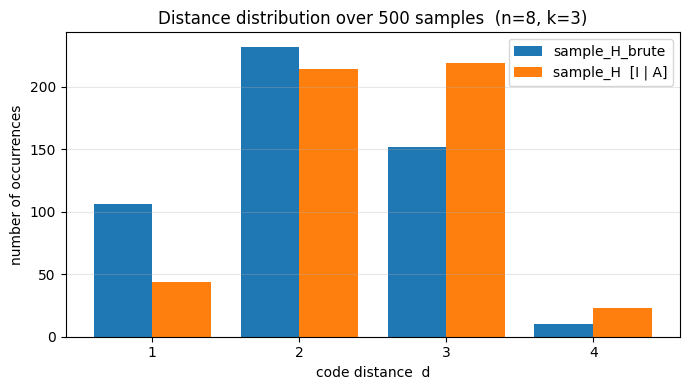

sample_H_brute: {1: 106, 2: 232, 3: 152, 4: 10}
sample_H      : {1: 44, 2: 214, 3: 219, 4: 23}


In [4]:
# ---- Compare distance distributions of the two sampling methods ----
n, k      = 8, 3
n_samples = 500

dist_brute = distance_distribution(lambda: sample_H_brute(n, k), n_samples)
dist_std   = distance_distribution(lambda: sample_H(n, k),       n_samples)

all_d = sorted(set(dist_brute) | set(dist_std))
x     = np.arange(len(all_d))
w     = 0.4

plt.figure(figsize=(7, 4))
plt.bar(x - w / 2, [dist_brute.get(d, 0) for d in all_d], width=w, label='sample_H_brute')
plt.bar(x + w / 2, [dist_std.get(d, 0)   for d in all_d], width=w, label='sample_H  [I | A]')
plt.xticks(x, all_d)
plt.xlabel('code distance  d')
plt.ylabel('number of occurrences')
plt.title(f'Distance distribution over {n_samples} samples  (n={n}, k={k})')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('sample_H_brute:', dist_brute)
print('sample_H      :', dist_std)

## Classical Code Define

In [5]:
code = ClassicalCode(np.array([[1, 1, 0],
                                [0, 1, 1]]))
print(code)


ClassicalCode(n=3, k=1, m=2)


In [6]:
n, k = 3, 1
code_random1 = ClassicalCode(sample_H(n,k))
code_random2 = ClassicalCode(sample_H_brute(n,k))
print(code_random1)
print(code_random1.d)

ClassicalCode(n=3, k=1, m=2)
1


In [7]:
# ---- Sanity checks ----
ch_test = LogicalChannel(code, 3, 0.1)
assert np.allclose(ch_test.U @ ch_test.U.T, np.eye(code.dim)), 'U is not unitary'
_rho_test = np.array([[0.7, 0.0], [0.0, 0.3]], dtype=complex)
assert np.allclose(ch_test(0, _rho_test), _rho_test), 'logical_channel(0) is not identity'
print('LogicalChannel.U is unitary (U @ U.T = I)')
print('LogicalChannel t=0 is identity on logical space')

LogicalChannel.U is unitary (U @ U.T = I)
LogicalChannel t=0 is identity on logical space


In [8]:
U = code.build_logical_unitary()
U_dag = U.T.conj()

print(U)

#print(code.x_string([1, 1, 1]))
M = U @ (0.3 * code.basis_state(0) + 0.7 * code.basis_state(7)) @ U_dag

print(partial_trace_syndrome(M, code))

[[1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]]
[[0.3+0.j 0. +0.j]
 [0. +0.j 0.7+0.j]]


# Logical Channel Sanity Check

In [9]:
# No Error Must be Identity
n, k = 3, 1
q = 0.1
T_max = 50

c = ClassicalCode(sample_H(n,k))

channel = LogicalChannel(c, T_max, q, p_error=perfect_physical_error, syndrome=perfect_syndrome(c))

a = 0.3

rho_in = a * logical_basis_state(c, 0) + (1-a) * logical_basis_state(c, 1)

rho_out = channel(T_max, rho_in)

print(rho_in == rho_out)


[[ True  True]
 [ True  True]]


In [10]:
# Simple Case


In [11]:
# For the case of upto 2 errors allowed in the whole circuit
# ------------------------------------------------------------------
# Brute-force fault-path enumeration -> logical stochastic matrix A[i,j].
#
# Independent reimplementation of LogicalChannel's model (rebuilds decode/label
# from `code` primitives, does NOT reuse channel internals) so it can verify the
# channel.  Per time step there are  n data-error + m=(n-k) syndrome-error
# locations => (2n-k)*T fault locations in the whole circuit.  We sum over every
# fault path with total weight <= max_faults, weighting by its probability.
#
# Dynamics matching LogicalChannel: at step t, s_t = H d_t (+) e_t (+) e_{t-1},
# the net X applied is  d_t (+) decoder[s_t], and the whole circuit applies X^F
# with F = XOR_t (d_t (+) decoder[s_t]).  Logical input j (codeword c_j) reads
# out as logical label l(c_j (+) F).
#
# NOTE on normalization.  Each path carries its full i.i.d. probability
# q^w (1-q)^(L-w).  Summing ALL weights gives columns = 1 (a proper channel,
# equals LogicalChannel).  Truncating at max_faults keeps only a subset, so the
# raw columns sum to P(w <= max_faults) < 1 -- the dropped >=(max_faults+1)-fault
# mass.  normalize=True divides that out, giving the channel CONDITIONED on
# w <= max_faults (columns = 1).
import itertools
from error_models import iid_bitflip_error, iid_syndrome


def brute_logical_channel(code, T, q, max_faults=2, normalize=True,
                          syndrome=None, p_error=iid_bitflip_error):
    """Logical column-stochastic matrix from fault paths with total weight <= max_faults.

    max_faults=None sums ALL weights (exact; matches LogicalChannel).
    normalize=True renormalizes a truncation to columns = 1 (condition on <= max_faults).
    """
    n, m, k = code.n, code.m, code.k
    if syndrome is None:
        syndrome = iid_syndrome(code, q)
    memory   = syndrome.memory
    zero_syn = tuple([0] * m)

    # independent decode/label tables
    codespace = sorted(y for y in range(code.dim)
                       if code.syndrome(code.to_bits(y)) == zero_syn)
    log_idx   = {y: l for l, y in enumerate(codespace)}
    def frombits(bits):                      # inverse of code.to_bits (MSB first)
        v = 0
        for i, b in enumerate(bits):
            v |= int(b) << (n - 1 - i)
        return v
    labels = [log_idx[x ^ frombits(code.decoder[code.syndrome(code.to_bits(x))])]
              for x in range(code.dim)]

    dimL = 2 ** k
    A    = np.zeros((dimL, dimL))
    # fault locations: n data bits + m syndrome bits, per step
    locs = ([('D', t, b) for t in range(T) for b in range(n)]
            + [('E', t, b) for t in range(T) for b in range(m)])
    L    = len(locs)                         # = (2n-k)*T

    def contribution(active):
        D = [[0] * n for _ in range(T)]
        E = [[0] * m for _ in range(T)]
        for kind, t, b in active:
            (D if kind == 'D' else E)[t][b] = 1
        D = [tuple(x) for x in D]
        E = [tuple(x) for x in E]
        prob, e_prev, F, hist = 1.0, zero_syn, 0, [zero_syn] * memory
        for t in range(T):
            d, e = D[t], E[t]
            prob *= p_error(d, q)                                  # physical error
            prob *= syndrome.prob(e, tuple(hist[:memory]))        # syndrome error
            if prob == 0.0:
                return None
            s = tuple(code.syndrome(d)[i] ^ e[i] ^ e_prev[i] for i in range(m))
            F ^= frombits(d) ^ frombits(code.decoder[s])
            e_prev, hist = e, [e] + hist
        return prob, F

    weights = range(L + 1) if max_faults is None else range(min(max_faults, L) + 1)
    for w in weights:
        for active in itertools.combinations(locs, w):
            res = contribution(active)
            if res is None:
                continue
            prob, F = res
            for j in range(dimL):
                A[labels[codespace[j] ^ F], j] += prob

    if normalize:                            # condition on w <= max_faults => columns = 1
        col = A.sum(axis=0, keepdims=True)
        A = np.divide(A, col, out=np.zeros_like(A), where=col > 0)
    return A


# ---- exact cross-check: full enumeration must equal LogicalChannel ----
code_v = ClassicalCode(np.array([[1, 1, 0], [0, 1, 1]]))
for T in (2, 3):
    A_full = brute_logical_channel(code_v, T, 0.2, max_faults=None)   # all faults, normalized (=raw)
    A_lc   = LogicalChannel(code_v, T, 0.2).stochastic_matrix(T)
    print(f'T={T}: full-enumeration vs LogicalChannel maxdiff = {np.max(np.abs(A_full - A_lc)):.2e}')




T=2: full-enumeration vs LogicalChannel maxdiff = 3.89e-16
T=3: full-enumeration vs LogicalChannel maxdiff = 1.20e-13


In [12]:
# ---- the <=2-fault channel, conditioned on <=2 faults (columns = 1) ----
T, q = 8, 0.05
A2 = brute_logical_channel(code_v, T, q, max_faults=2, normalize = False)               # normalize=True (default)
print(f'\n<=2-fault logical channel, conditioned (T={T}, q={q}):')
print(np.round(A2, 6))
print('column sums:', np.round(A2.sum(0), 6))

B = (13*T -6) * (q**2)
print(B)

print(np.array([[1-B,B],[B,1-B]]))


<=2-fault logical channel, conditioned (T=8, q=0.05):
[[0.641849 0.034887]
 [0.034887 0.641849]]
column sums: [0.676736 0.676736]
0.24500000000000005
[[0.755 0.245]
 [0.245 0.755]]


# Logical Channel Result

In [13]:
#code = ClassicalCode(np.array([[1,1,0,0,0],[0,1,1,0,0],[0,0,1,1,0],[0,0,0,1,1]]))

code = ClassicalCode(np.array([[1,1,0],[0,1,1]]))

## Compare with Mathematica

### no sndrome error, iid physical error, Time step = 3

In [14]:
def theory_result_perfect_syndrome_t3(q,a):
    #This is the Mathematica Result for T = 3, no syndrome error, iid physical error theoretical result
    element = a*(1-6*q**2 + 4*q**3)**3 + q**2 *(9-6*q-54*q**2 + 72*q**3 + 84*q**4 -216*q**5 + 144*q**6 - 32*q**7)

    return np.array([[ element, 0 ],[0, 1-element]])

q = 0.1
Tmax = 3

channel =  LogicalChannel(code, Tmax, q, syndrome=perfect_syndrome(code), p_error=iid_bitflip_error)
a = 0.01
rho0= a * logical_basis_state(code, 0) + (1-a) * logical_basis_state(code, 1)

dim_L = 2 ** code.k

print(channel(Tmax, rho0))

print(theory_result_perfect_syndrome_t3(q,a))


[[0.08779613+0.j 0.        +0.j]
 [0.        +0.j 0.91220387+0.j]]
[[0.08779613 0.        ]
 [0.         0.91220387]]


### no physical error, iid syndrome error, T = 3 step

In [15]:
#see the resulting state when independent noise in physical and no error in syndrome. for T = 3 steps. compare it with the mathematica result.
def theory_result_perfect_physical_t3(q,a):
    element = a + 4*q**2-8*a*q**2 -4*q**3 + 8*a*q**3 - 8*q**4 +16*a*q**4 +16*q**5 -32*a*q**5 -8*q**6 + 16*a*q**6
    return np.array([[element,0],[0,1-element]])

q = 0.1
Tmax = 3

channel =  LogicalChannel(code, Tmax, q, p_error=perfect_physical_error, syndrome=iid_syndrome(code,q))
a = 0.3
rho0= a * logical_basis_state(code, 0) + (1-a) * logical_basis_state(code, 1)

dim_L = 2 ** code.k

print(channel(Tmax, rho0))

print(theory_result_perfect_physical_t3(q,a))




[[0.3141408+0.j 0.       +0.j]
 [0.       +0.j 0.6858592+0.j]]
[[0.3141408 0.       ]
 [0.        0.6858592]]


### iid syndrome error, iid physical error time step = 3

Can check and compare with the results with Mathematica file for other time steps as well.

In [16]:
q = 0.1
Tmax = 3

channel = LogicalChannel(code, Tmax, q)
a = 0.3
rho0 = a * logical_basis_state(code,0) + (1-a) * logical_basis_state(code,1)

dim_L = 2 ** code.k

print(channel(Tmax, rho0))

print(np.array([[(449661961*(1-a) + 1991744289 * a)/2441406250, 0],[0, (1991744289 * (1-a) + 449661961 * a)/2441406250]]))


[[0.37367262+0.j 0.        +0.j]
 [0.        +0.j 0.62632738+0.j]]
[[0.37367262 0.        ]
 [0.         0.62632738]]


## Logical Channel Characteristics

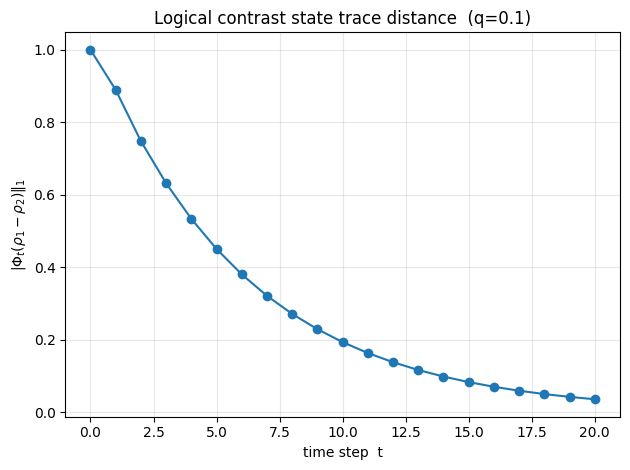

In [17]:
q = 0.1
Tmax = 20
channel = LogicalChannel(code, Tmax, q)

# contrast state rho1 - rho2  (traceless Hermitian)
rho = logical_basis_state(code, 0) - logical_basis_state(code, 1)
dim_L = 2 ** code.k


ts   = list(range(0, Tmax + 1))
dist = [trace_norm(channel(t, rho)) for t in ts]

plt.plot(ts, dist, marker='o')
plt.xlabel('time step  t')
plt.ylabel(r'$|\Phi_t(\rho_1-\rho_2)\|_1$')
plt.title(f'Logical contrast state trace distance  (q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

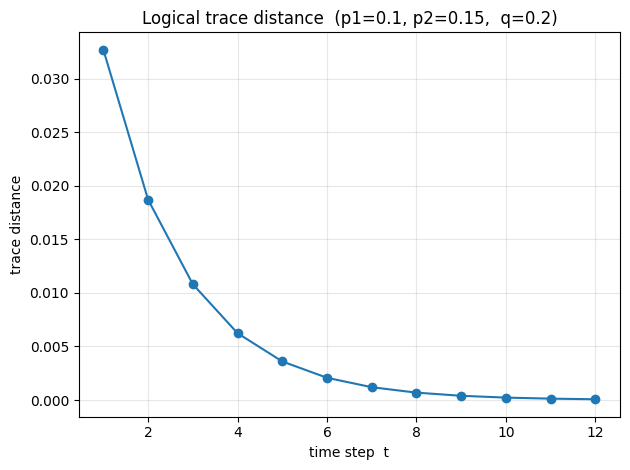

In [18]:
p1 = 0.1
p2 = 0.15
rho1 = input_state(code, p1)
rho2 = input_state(code, p2)
q    = 0.2
Tmax = 12
channel = LogicalChannel(code, Tmax, q)
ts   = list(range(1, Tmax + 1))

dist_vals = [trace_norm(channel(t, rho1 - rho2)) for t in ts]

plt.plot(ts, dist_vals, marker='o')
plt.xlabel('time step  t')
plt.ylabel(r'trace distance')
plt.title(f'Logical trace distance  (p1={p1}, p2={p2},  q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

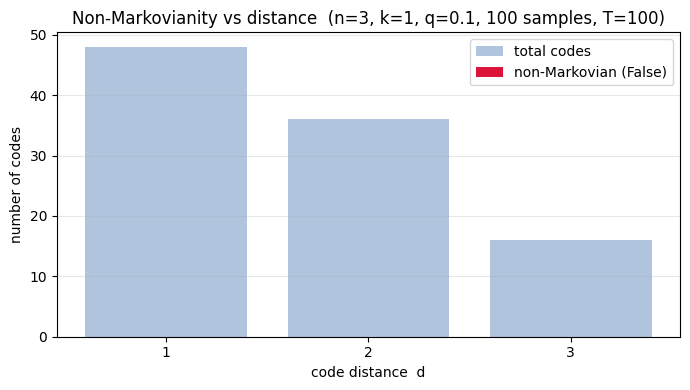

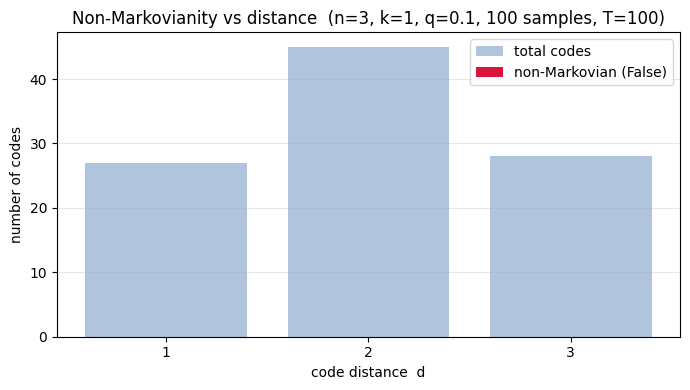

sample_H_brute: {1: {'total': 48, 'non_markovian': 0}, 2: {'total': 36, 'non_markovian': 0}, 3: {'total': 16, 'non_markovian': 0}}
sample_H      : {1: {'total': 27, 'non_markovian': 0}, 2: {'total': 45, 'non_markovian': 0}, 3: {'total': 28, 'non_markovian': 0}}


In [19]:
# ---- Monte Carlo: non-Markovianity of random codes, grouped by code distance ----
# NOTE: LogicalChannel builds 2^(2n) superoperators, so cost explodes with n
# (n=3 ~0.2s/sample, n=4 ~12s/sample). Keep n small or n_samples low.
def markovianity_vs_distance(sampler: Callable[[int, int], np.ndarray],
                             n: int, k: int, q: float,
                             n_samples: int = 100, T: int = 50,
                             plot: bool = True) -> dict[int, dict[str, int]]:
    """Sample random [n, k] codes, build their logical channels at noise q, and
    count how many are non-Markovian (stochastically non-divisible), by distance.

    Parameters
    ----------
    sampler   : Callable[[int, int], np.ndarray] -- returns a parity-check matrix
                H of shape (n-k, n) given (n, k).
    n, k      : int   -- code parameters.
    q         : float -- bit-flip noise rate.
    n_samples : int   -- number of random codes to draw.
    T         : int   -- time steps used by LogicalChannel.is_divisible.
    plot      : bool  -- show the histogram.

    Returns
    -------
    dict[int, dict[str, int]] -- {distance: {'total': , 'non_markovian': }}.
    """
    stats: dict[int, dict[str, int]] = {}
    for _ in range(n_samples):
        code      = ClassicalCode(sampler(n, k))
        channel   = LogicalChannel(code, T, q)
        divisible = channel.is_divisible()[0]
        s = stats.setdefault(code.d, {'total': 0, 'non_markovian': 0})
        s['total'] += 1
        if not divisible:
            s['non_markovian'] += 1
    stats = dict(sorted(stats.items()))

    if plot:
        ds     = list(stats)
        totals = [stats[d]['total']          for d in ds]
        nonm   = [stats[d]['non_markovian']  for d in ds]
        x      = np.arange(len(ds))
        plt.figure(figsize=(7, 4))
        plt.bar(x, totals, color='lightsteelblue', label='total codes')
        plt.bar(x, nonm,   color='crimson',        label='non-Markovian (False)')
        plt.xticks(x, ds)
        plt.xlabel('code distance  d')
        plt.ylabel('number of codes')
        plt.title(f'Non-Markovianity vs distance  '
                  f'(n={n}, k={k}, q={q}, {n_samples} samples, T={T})')
        plt.legend()
        plt.grid(alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()
    return stats


n, k, q   = 3, 1, 0.1
T_max = 100
n_samples = 100

res_brute = markovianity_vs_distance(sample_H_brute, n, k, q, n_samples=n_samples, T=T_max)
res_std   = markovianity_vs_distance(sample_H,       n, k, q, n_samples=n_samples, T=T_max)

print('sample_H_brute:', res_brute)
print('sample_H      :', res_std)

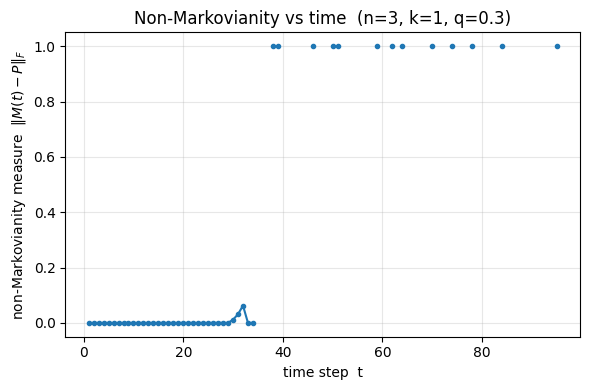

In [20]:
# ---- Non-Markovianity measure vs time (fixed q) ----
# measure(t) = stochastic_distance( A_t @ inv(A_{t-1}) ):  how far the one-step
# propagator is from being a stochastic matrix.  Markovian => stays at 0.
from measures import stochastic_distance

q    = 0.3
Tmax = 100
channel = LogicalChannel(code, Tmax, q)

A  = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
ts = list(range(1, Tmax + 1))

measure = []
for t in ts:
    try:
        M = A[t] @ np.linalg.inv(A[t - 1])
    except np.linalg.LinAlgError:
        measure.append(np.nan)            # singular step: propagator undefined
    else:
        measure.append(stochastic_distance(M))

plt.figure(figsize=(6, 4))
plt.plot(ts, measure, marker='o', ms=3)
plt.xlabel('time step  t')
plt.ylabel(r'non-Markovianity measure  $\|M(t)-P\|_F$')
plt.title(f'Non-Markovianity vs time  (n={code.n}, k={code.k}, q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

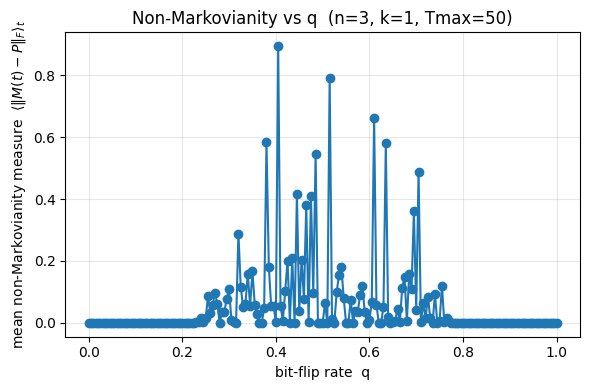

{np.float64(0.0): np.float64(0.0), np.float64(0.1): np.float64(0.0), np.float64(0.2): np.float64(0.014221), np.float64(0.3): np.float64(0.055633), np.float64(0.4): np.float64(0.037947), np.float64(0.5): np.float64(0.079637), np.float64(0.6): np.float64(0.002686), np.float64(0.7): np.float64(0.0), np.float64(0.8): np.float64(0.0), np.float64(0.9): np.float64(0.0), np.float64(1.0): np.float64(0.0)}


In [21]:
# ---- Non-Markovianity measure vs noise rate q (mean over time) ----
# For each q, average the per-step measure over t = 1..Tmax.
Tmax = 50
qs   = np.arange(0.0, 1.0 + 1e-9, 0.005)

mean_measure = []
for q in qs:
    channel = LogicalChannel(code, Tmax, q)
    A = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
    vals = []
    for t in range(1, Tmax + 1):
        try:
            M = A[t] @ np.linalg.inv(A[t - 1])
        except np.linalg.LinAlgError:
            vals.append(np.nan)
        else:
            vals.append(stochastic_distance(M))
    mean_measure.append(np.nanmean(vals))

plt.figure(figsize=(6, 4))
plt.plot(qs, mean_measure, marker='o')
plt.xlabel('bit-flip rate  q')
plt.ylabel(r'mean non-Markovianity measure  $\langle\|M(t)-P\|_F\rangle_t$')
plt.title(f'Non-Markovianity vs q  (n={code.n}, k={code.k}, Tmax={Tmax})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(dict(zip(np.round(qs, 1), np.round(mean_measure, 6))))

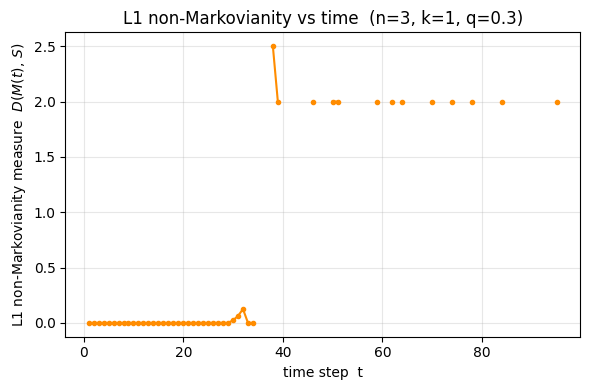

In [22]:
# ---- L1 stochastic-distance measure vs time (fixed q) ----
# Same one-step propagator  M(t) = A_t @ inv(A_{t-1})  as above, but scored with
# the L1 penalty distance: sum of |negative entries| + |column-sum deviations|.
# Markovian (column-stochastic propagator) => stays at 0.
from measures import l1_stochastic_distance

q    = 0.3
Tmax = 100
channel = LogicalChannel(code, Tmax, q)

A  = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
ts = list(range(1, Tmax + 1))

measure = []
for t in ts:
    try:
        M = A[t] @ np.linalg.inv(A[t - 1])
    except np.linalg.LinAlgError:
        measure.append(np.nan)            # singular step: propagator undefined
    else:
        measure.append(l1_stochastic_distance(M))

plt.figure(figsize=(6, 4))
plt.plot(ts, measure, marker='o', ms=3, color='darkorange')
plt.xlabel('time step  t')
plt.ylabel(r'L1 non-Markovianity measure  $D(M(t),\,S)$')
plt.title(f'L1 non-Markovianity vs time  (n={code.n}, k={code.k}, q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


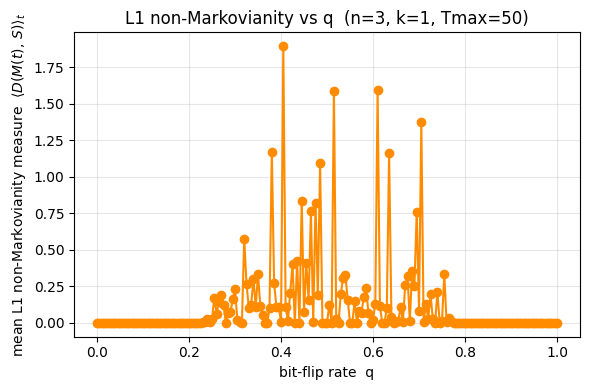

{np.float64(0.0): np.float64(0.0), np.float64(0.1): np.float64(0.0), np.float64(0.2): np.float64(0.028442), np.float64(0.3): np.float64(0.111265), np.float64(0.4): np.float64(0.075893), np.float64(0.5): np.float64(0.159275), np.float64(0.6): np.float64(0.005372), np.float64(0.7): np.float64(0.0), np.float64(0.8): np.float64(0.0), np.float64(0.9): np.float64(0.0), np.float64(1.0): np.float64(0.0)}


In [23]:
# ---- L1 stochastic-distance measure vs noise rate q (mean over time) ----
# For each q, average the per-step L1 penalty distance over t = 1..Tmax.
Tmax = 50
qs   = np.arange(0.0, 1.0 + 1e-9, 0.005)

mean_measure = []
for q in qs:
    channel = LogicalChannel(code, Tmax, q)
    A = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
    vals = []
    for t in range(1, Tmax + 1):
        try:
            M = A[t] @ np.linalg.inv(A[t - 1])
        except np.linalg.LinAlgError:
            vals.append(np.nan)
        else:
            vals.append(l1_stochastic_distance(M))
    mean_measure.append(np.nanmean(vals))

plt.figure(figsize=(6, 4))
plt.plot(qs, mean_measure, marker='o', color='darkorange')
plt.xlabel('bit-flip rate  q')
plt.ylabel(r'mean L1 non-Markovianity measure  $\langle D(M(t),\,S) \rangle_t $')
plt.title(f'L1 non-Markovianity vs q  (n={code.n}, k={code.k}, Tmax={Tmax})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(dict(zip(np.round(qs, 1), np.round(mean_measure, 6))))


# Non-Markovian Case Explore

In [24]:
n = 6
k = 1
Tmax = 30
q = 0.8

code = ClassicalCode(sample_H_brute(n,k))
channel = LogicalChannel(code, Tmax, q)
divisible = channel.is_divisible()



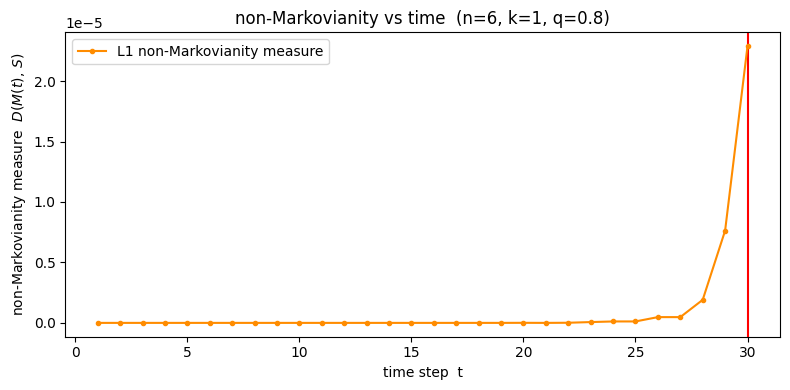

In [25]:
A  = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
ts = list(range(1, Tmax + 1))

measure_l1 = []
measure_frob = []

plt.figure(figsize=(8, 4))

for t in ts:
    try:
        M = A[t] @ np.linalg.inv(A[t - 1])
    except np.linalg.LinAlgError:
        measure_l1.append(np.nan)  # singular step: propagator undefined
        measure_frob.append(np.nan)
    else:
        if not divisible[1][t]:
            plt.axvline(t, color='r')
        measure_l1.append(l1_stochastic_distance(M))
        measure_frob.append(stochastic_distance(M))


plt.plot(ts, measure_l1, marker='o', ms=3, color='darkorange', label='L1 non-Markovianity measure')
#plt.plot(ts, measure_frob, marker='o', ms=3, color='blue', label = r'Frobenious measure')
plt.xlabel('time step  t')
plt.ylabel(r'non-Markovianity measure  $D(M(t),\,S)$')
plt.title(f'non-Markovianity vs time  (n={code.n}, k={code.k}, q={q})')

plt.legend()
plt.tight_layout()
plt.show()


## Non-Markovian syndrome-error model (no physical errors)

Syndrome error `e_t` repeats the previous one `e_{t-1}` with probability `q`, otherwise it is freshly drawn from an i.i.d. bit-flip(`p`) distribution — a sticky (memory-1) process on the syndrome-error sequence (`sticky_syndrome`). The data qubits are noiseless (`perfect_physical_error`), so the only dynamics come from the temporally correlated measurement noise. Set `q` (memory) and `p` (fresh bit-flip rate) below.

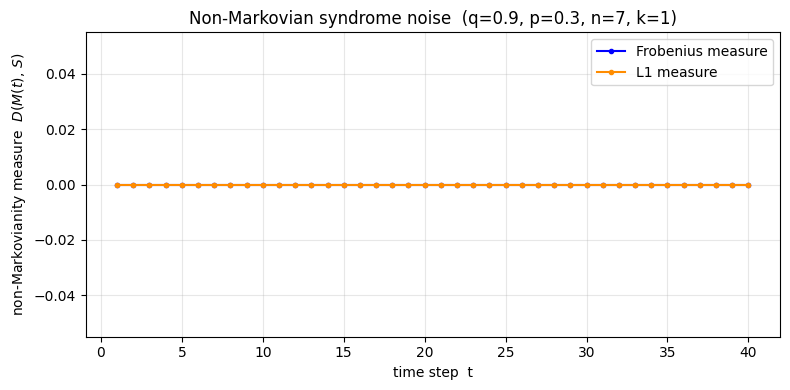

divisible (Markovian) over all steps: True


In [26]:
# ---- Non-Markovian (temporally correlated) syndrome errors, no physical errors ----
# Syndrome-error model:  e_t = e_{t-1}  with probability q,
#                        else freshly drawn from an i.i.d. bit-flip(p) distribution.
# The physical channel is PERFECT (no data errors), so every bit of logical
# dynamics comes from the temporally correlated syndrome-measurement noise.
from error_models import perfect_physical_error, sticky_syndrome
from measures import stochastic_distance, l1_stochastic_distance

q    = 0.9      # probability the syndrome error repeats the previous step (memory)
p    = 0.3      # bit-flip parameter of the fresh-draw distribution
Tmax = 40

#code_nm = ClassicalCode(np.array([[1, 1, 0], [0, 1, 1]]))         # swap in any code here

n = 7
k = 1

code_nm = ClassicalCode(sample_H_brute(n,k))

channel = LogicalChannel(code_nm, Tmax, q,
                         p_error=perfect_physical_error,           # no physical errors
                         syndrome=sticky_syndrome(code_nm, q, p))  # correlated syndrome noise

A         = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
ts        = list(range(1, Tmax + 1))
divisible = channel.is_divisible()

measure_frob, measure_l1 = [], []
for t in ts:
    try:
        M = A[t] @ np.linalg.inv(A[t - 1])
    except np.linalg.LinAlgError:
        measure_frob.append(np.nan)
        measure_l1.append(np.nan)
    else:
        measure_frob.append(stochastic_distance(M))
        measure_l1.append(l1_stochastic_distance(M))

plt.figure(figsize=(8, 4))
plt.plot(ts, measure_frob, marker='o', ms=3, color='blue',       label='Frobenius measure')
plt.plot(ts, measure_l1,   marker='o', ms=3, color='darkorange', label='L1 measure')
for t in ts:
    if not divisible[1][t]:
        plt.axvline(t, color='r', alpha=0.3)
plt.xlabel('time step  t')
plt.ylabel(r'non-Markovianity measure  $D(M(t),\,S)$')
plt.title(f'Non-Markovian syndrome noise  '
          f'(q={q}, p={p}, n={code_nm.n}, k={code_nm.k})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('divisible (Markovian) over all steps:', divisible[0])

## Experimental two-step-history model (`exp_syndrome_1`)

An arbitrary, explicitly history-dependent syndrome process (memory 2) for probing non-Markovianity. For `t ≥ 2`: if `(e_{t-1} XOR e_{t-2})` is the all-ones string, the next syndrome error is forced to all-ones with probability `q` (else i.i.d. bit-flip(`p`)); otherwise it is i.i.d. bit-flip(`p`). The data qubits are noiseless (`perfect_physical_error`). With `q = 1` the all-ones history deterministically pins `e_t`. Red lines mark steps where the one-step propagator fails to be stochastic (non-divisible ⇒ non-Markovian).

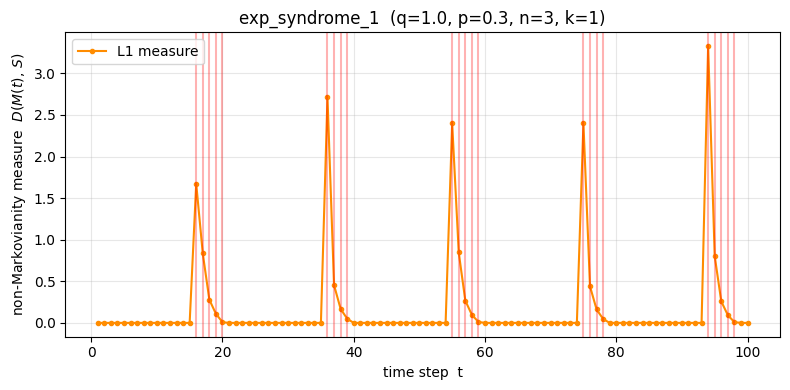

divisible (Markovian) over all steps: False
non-divisible steps: [16, 17, 18, 19, 20, 36, 37, 38, 39, 55, 56, 57, 58, 59, 75, 76, 77, 78, 94, 95, 96, 97, 98]


In [27]:
# ---- Experimental two-step-history syndrome model (exp_syndrome_1) ----
# For t >= 2, if  (e_{t-1} XOR e_{t-2}) == 11...1  (all-ones), then e_t is forced
# to all-ones with probability q, else i.i.d. bit-flip(p).  Otherwise e_t is just
# i.i.d. bit-flip(p).  Physical channel is perfect (no data errors).
# Both q (forcing prob) and p (i.i.d. fallback rate) are baked into exp_syndrome_1.
from error_models import perfect_physical_error, exp_syndrome_1
from measures import stochastic_distance, l1_stochastic_distance

q    = 1.0      # forcing probability when the all-ones history condition fires
p    = 0.3      # i.i.d. bit-flip fallback rate
Tmax = 100

code_exp = ClassicalCode(np.array([[1, 1, 0],
                                    [0, 1, 1]]))        # swap in any code here
channel  = LogicalChannel(code_exp, Tmax, q,
                          p_error=perfect_physical_error,           # no physical errors
                          syndrome=exp_syndrome_1(code_exp, q, p))  # 2-step history process

A         = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
ts        = list(range(1, Tmax + 1))
divisible = channel.is_divisible()

measure_frob, measure_l1 = [], []
for t in ts:
    try:
        M = A[t] @ np.linalg.inv(A[t - 1])
    except np.linalg.LinAlgError:
        measure_frob.append(np.nan)
        measure_l1.append(np.nan)
    else:
        measure_frob.append(stochastic_distance(M))
        measure_l1.append(l1_stochastic_distance(M))

plt.figure(figsize=(8, 4))
#plt.plot(ts, measure_frob, marker='o', ms=3, color='blue',       label='Frobenius measure')
plt.plot(ts, measure_l1,   marker='o', ms=3, color='darkorange', label='L1 measure')
for t in ts:
    if not divisible[1][t]:
        plt.axvline(t, color='r', alpha=0.3)
plt.xlabel('time step  t')
plt.ylabel(r'non-Markovianity measure  $D(M(t),\,S)$')
plt.title(f'exp_syndrome_1  (q={q}, p={p}, n={code_exp.n}, k={code_exp.k})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/exp_syndrome_1')
plt.show()

print('divisible (Markovian) over all steps:', divisible[0])
print('non-divisible steps:', [t for t in ts if not divisible[1][t]])

saved: plots/exp_syndrome_1 mean non-Markovianity vs q (p=0.3, n=3, k=1, Tmax=40).png


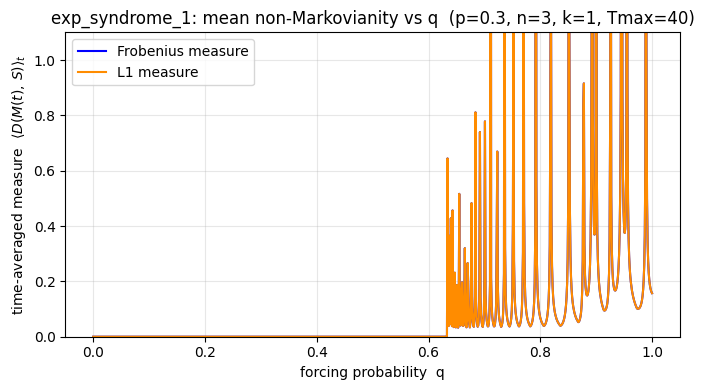

In [28]:
# ---- exp_syndrome_1: time-averaged non-Markovianity measure vs q ----
# Coarse 0.1 grid on [0.0, 0.5], then a fine 0.001 grid on [0.6, 1.0] so the
# behaviour near q -> 1 is resolved.  (Do NOT np.round(qs, 1): that collapses the
# fine grid back onto the 0.1 grid and was the bug in the previous version.)
import os, re
from error_models import perfect_physical_error, exp_syndrome_1
from measures import stochastic_distance, l1_stochastic_distance

p    = 0.3      # i.i.d. bit-flip fallback rate
Tmax = 40
qs   = np.concatenate([np.arange(0.0, 0.6, 0.1),            # coarse 0.0 .. 0.5
                       np.arange(0.6, 1.0 + 1e-9, 0.001)])  # fine   0.6 .. 1.0

code_exp = ClassicalCode(np.array([[1, 1, 0],
                                    [0, 1, 1]]))        # swap in any code here

mean_frob, mean_l1 = [], []
for q in qs:
    channel = LogicalChannel(code_exp, Tmax, q,
                             p_error=perfect_physical_error,
                             syndrome=exp_syndrome_1(code_exp, q, p))
    A = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
    vf, vl = [], []
    for t in range(1, Tmax + 1):
        try:
            M = A[t] @ np.linalg.inv(A[t - 1])
        except np.linalg.LinAlgError:
            vf.append(np.nan); vl.append(np.nan)        # singular step
        else:
            vf.append(stochastic_distance(M))
            vl.append(l1_stochastic_distance(M))
    mean_frob.append(np.nansum(vf) / Tmax)              # sum of measures / total steps
    mean_l1.append(np.nansum(vl) / Tmax)

title = (f'exp_syndrome_1: mean non-Markovianity vs q  '
         f'(p={p}, n={code_exp.n}, k={code_exp.k}, Tmax={Tmax})')

plt.figure(figsize=(7, 4))
plt.plot(qs, mean_frob, color='blue',       label='Frobenius measure')
plt.plot(qs, mean_l1,   color='darkorange', label='L1 measure')
plt.xlabel('forcing probability  q')
plt.ylabel(r'time-averaged measure  $\langle D(M(t),\,S)\rangle_t$')
plt.title(title)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# save to plots/ with a filename derived from the title (strip Windows-illegal chars)
os.makedirs('plots', exist_ok=True)
fname = re.sub(r'[<>:"/\|?*]', '', title).strip()
fname = re.sub(r'\s+', ' ', fname) + '.png'
plt.savefig(os.path.join('plots', fname), dpi=150, bbox_inches='tight')
print('saved:', os.path.join('plots', fname))

plt.show()

#print('Frobenius:', dict(zip(np.round(qs, 3), np.round(mean_frob, 6))))
#print('L1       :', dict(zip(np.round(qs, 3), np.round(mean_l1, 6))))
